# Pytorch Custom Datasets

## 0. Importing pytorch and setting up device-agnostic code

In [2]:
import torch
from torch import nn

torch.__version__

'2.7.0'

In [3]:
# Setup device-agnostic code
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data

In [4]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
# 
# # If the image folder doesn't exist, download it and prepare it ...
# if image_path.is_dir():
#     print(f"{image_path} directory already exists... skipping download")
# else:
#     print(f"{image_path} does not exist, creating one...")
#     image_path.mkdir(parents=True, exist_ok=True)
# # Download pizza, steak and sushi data
# with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
#     request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#     print("Downloaded pizza, steak, sushi data...")
#     f.write(request.content)
# 
# # Unzip pizza, steak, sushi data
# with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#     print("Unzipping pizza, steak and sushi data...")
#     zip_ref.extractall(image_path)

## 2. Data preparation & exploration

In [5]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning it's contents."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'


In [7]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image

In [8]:
image_path

WindowsPath('data/pizza_steak_sushi')

The image path is: data\pizza_steak_sushi\train\pizza\765799.jpg
Image class: pizza
Image height: 512
Image width 511


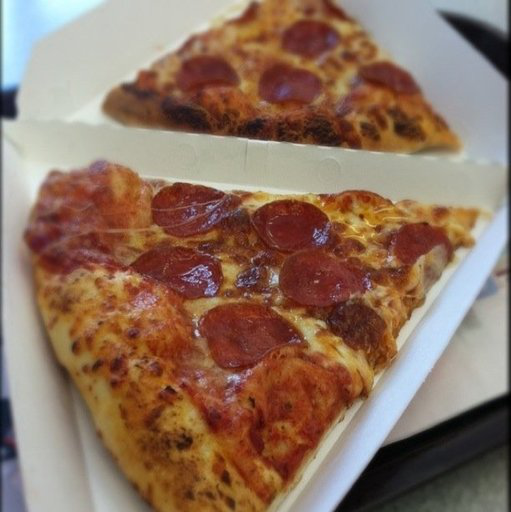

In [9]:
import random
from PIL import Image

# Set a seed
# random.seed(42)

# 1. Get all image path
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a radom image
random_image_path = random.choice(image_path_list)

# 3. Get image class
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Display some meta data
print(f"The image path is: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width {img.width}")
img

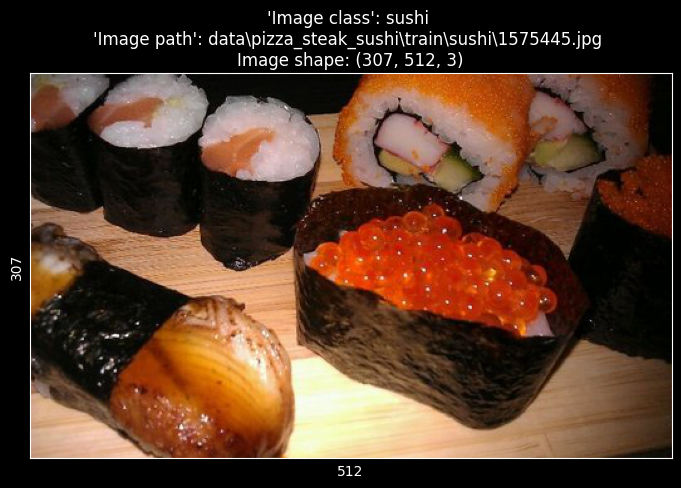

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get all image path
all_image_paths = list(image_path.glob("*/*/*.jpg"))

# 2 .Pick a random image path
random_image_path = random.choice(all_image_paths)

# 3. Get image class
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)
image_as_array = np.asarray(img)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_xlabel(img.width)
ax.set_ylabel(img.height)
ax.set_title(f"'Image class': {image_class} \n'Image path': {random_image_path} \nImage shape: {image_as_array.shape}")
ax.imshow(img)
plt.show()

## 3. Transforming data

In [30]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torch.transforms`

In [31]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize the images to 64X64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor(),
])

In [32]:
data_transform(img).dtype

torch.float32

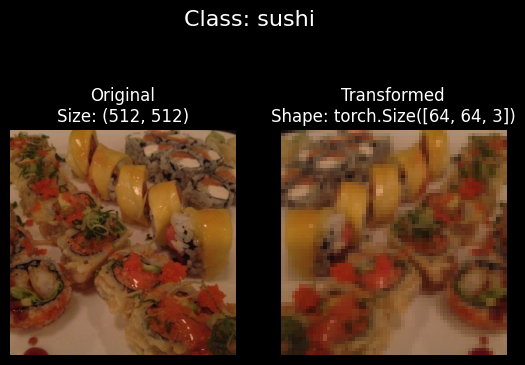

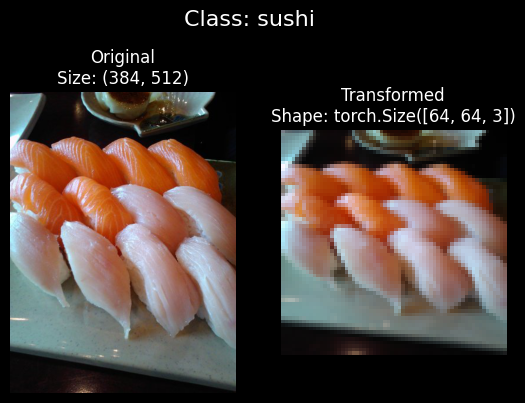

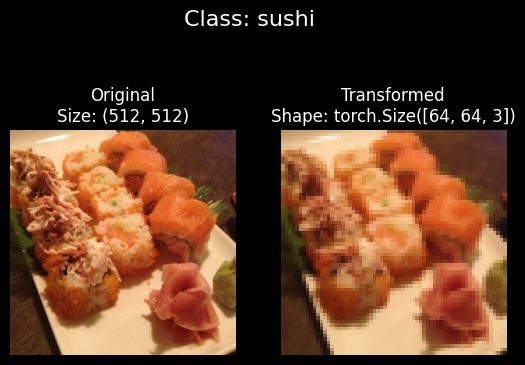

In [34]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot the target image
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3)

## 4. Option1: Loading image data using `ImageFolder`

In [41]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(test_data)

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=warn)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [43]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [44]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [46]:
# Check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [48]:
# Index on train_data dataset to get a image and label separately
img, label = train_data[0][0], train_data[0][1]
img

tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0863],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0706],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0902, 0.0902, 0.

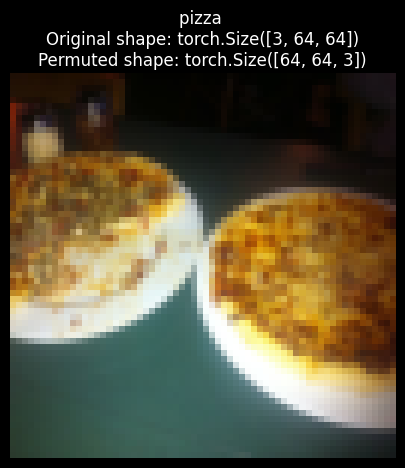

In [62]:
img_permute = img.permute(1, 2, 0)
plt.figure(figsize=(10, 5))
plt.imshow(img_permute)
plt.axis('off')
plt.title(f"{class_names[label]} \nOriginal shape: {img.shape}\nPermuted shape: {img_permute.shape}")
plt.show()

### 4.1 Turn loaded images into `DataLoader`'s

In [70]:
# Turn our data into a DataLoader's
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset=train_data,
                               batch_size=BATCH_SIZE,
                               shuffle=True,
                               num_workers=4)

test_data_loader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=2)

test_data_loader, train_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x1e3d5baaad0>,
 <torch.utils.data.dataloader.DataLoader at 0x1e3d5ba87f0>)

In [ ]:
len(train_data_loader), len(train_data)

(8, 225)

In [79]:
img, label = next(iter(train_data_loader))

print(f"Image shape: {img.shape}\nLabel shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])
